e# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [34]:
import pandas as pd

df_clean = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")

print(df_clean.head())
print(df_clean.shape)
print(df_clean.columns)


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

       Health_Notes  Watering_Amount_ml  Watering_Frequency_days  \
0  Yellowing leaves                 205                        3   
1               NaN                 191                        1   
2    Brittle leaves                 477                        5   
3           New bud                 207                        1   
4           Wilting                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct m

Checking the data types

In [35]:
print(df_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plant_ID                 1000 non-null   str    
 1   Height_cm                1000 non-null   float64
 2   Leaf_Count               1000 non-null   int64  
 3   New_Growth_Count         1000 non-null   int64  
 4   Health_Notes             882 non-null    str    
 5   Watering_Amount_ml       1000 non-null   int64  
 6   Watering_Frequency_days  1000 non-null   int64  
 7   Sunlight_Exposure        1000 non-null   str    
 8   Room_Temperature_C       1000 non-null   float64
 9   Humidity_%               1000 non-null   float64
 10  Fertilizer_Type          805 non-null    str    
 11  Fertilizer_Amount_ml     1000 non-null   int64  
 12  Pest_Presence            798 non-null    str    
 13  Pest_Severity            758 non-null    str    
 14  Soil_Moisture_%          1000 non-nu

In [36]:
print(df_clean.isnull().sum())

Plant_ID                     0
Height_cm                    0
Leaf_Count                   0
New_Growth_Count             0
Health_Notes               118
Watering_Amount_ml           0
Watering_Frequency_days      0
Sunlight_Exposure            0
Room_Temperature_C           0
Humidity_%                   0
Fertilizer_Type            195
Fertilizer_Amount_ml         0
Pest_Presence              202
Pest_Severity              242
Soil_Moisture_%              0
Soil_Type                    0
Health_Score                 0
dtype: int64


I belive that stuff about pests, fertilizer and health notes are quite out of scope so i will be droping them

In [37]:
columns_to_drop = [
    "Health_Notes",
    "Fertilizer_Type",
    "Fertilizer_Amount_ml",
    "Pest_Presence",
    "Pest_Severity"
]


In [38]:
df_clean = df_clean.drop(columns=columns_to_drop)

print(df_clean.head())
print(df_clean.info())
print(df_clean.isnull().sum())


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

   Watering_Amount_ml  Watering_Frequency_days  \
0                 205                        3   
1                 191                        1   
2                 477                        5   
3                 207                        1   
4                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct morning sun                22.6        68.9   
2             Indirect light all day                17.2      

In [39]:
print(df_clean.describe(include="all"))
print("Duplicate rows:", df_clean.duplicated().sum())
categorical_columns = [
    "Plant_ID",
    "Sunlight_Exposure",
    "Soil_Type"
]

for col in categorical_columns:
    print("\n", col)
    print(df_clean[col].value_counts())

                    Plant_ID    Height_cm   Leaf_Count  New_Growth_Count  \
count                   1000  1000.000000  1000.000000       1000.000000   
unique                    20          NaN          NaN               NaN   
top     Dracaena trifasciata          NaN          NaN               NaN   
freq                      59          NaN          NaN               NaN   
mean                     NaN    25.723450    27.038000          4.520000   
std                      NaN    10.448949    12.743585          2.844942   
min                      NaN    -4.140000     5.000000          0.000000   
25%                      NaN    19.030000    16.000000          2.000000   
50%                      NaN    25.965000    26.000000          5.000000   
75%                      NaN    32.627500    38.000000          7.000000   
max                      NaN    57.600000    49.000000          9.000000   

        Watering_Amount_ml  Watering_Frequency_days      Sunlight_Exposure  \
count    

In [40]:
numeric_columns = [
    "Height_cm",
    "Leaf_Count",
    "New_Growth_Count",
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Room_Temperature_C",
    "Humidity_%",
    "Soil_Moisture_%",
    "Health_Score"
]

for col in numeric_columns:
    print("\n", col)
    print("min:", df_clean[col].min())
    print("max:", df_clean[col].max())
    print("mean:", df_clean[col].mean())


 Height_cm
min: -4.14
max: 57.6
mean: 25.723449999999996

 Leaf_Count
min: 5
max: 49
mean: 27.038

 New_Growth_Count
min: 0
max: 9
mean: 4.52

 Watering_Amount_ml
min: 51
max: 499
mean: 279.337

 Watering_Frequency_days
min: 1
max: 6
mean: 3.424

 Room_Temperature_C
min: 14.3
max: 34.6
mean: 23.947599999999998

 Humidity_%
min: 30.0
max: 80.0
mean: 54.707300000000004

 Soil_Moisture_%
min: 10.1
max: 59.9
mean: 34.728699999999996

 Health_Score
min: 1
max: 5
mean: 3.04


 hmmmm Height_cm
min: -4.14 this is weird minus height on plant
could be that the leafe died or smthing but i will jsut remove it bc its weird outlier

In [41]:
bad_height_rows = df_clean[df_clean["Height_cm"] <= 0]

print("Bad height rows:", len(bad_height_rows))
print(bad_height_rows)

Bad height rows: 8
                   Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
16                Aloe vera      -2.60          24                 3   
146            Ficus lyrata      -0.02          34                 2   
150   Dieffenbachia seguine      -0.17          30                 5   
372            Ficus lyrata      -0.23          43                 6   
576  Zamioculcas zamiifolia      -4.02          32                 7   
778        Begonia maculata      -3.20          14                 6   
819        Begonia maculata      -2.02          19                 2   
937               Aloe vera      -4.14          16                 9   

     Watering_Amount_ml  Watering_Frequency_days  \
16                  339                        1   
146                 300                        2   
150                 271                        1   
372                 140                        1   
576                 277                        2   
778                 

so its only 8 rows. i will sacrifice them

In [42]:
df_clean = df_clean[df_clean["Height_cm"] > 0].copy()

Because the dataset used categorical sunlight descriptions, we converted them into simulated light sensor ranges to match the IoT contract.

In [43]:
import numpy as np

light_ranges = {
    "Low light corner": (0, 200),
    "Filtered sunlight through curtain": (200, 450),
    "Indirect light all day": (350, 600),
    "3h direct morning sun": (600, 850),
    "6h full sun": (800, 1023)
}

rng = np.random.default_rng(42)

df_clean["Light"] = df_clean["Sunlight_Exposure"].apply(
    lambda value: rng.integers(
        light_ranges[value][0],
        light_ranges[value][1] + 1
    )
)

print(df_clean[["Sunlight_Exposure", "Light"]].head(20))
print(df_clean.groupby("Sunlight_Exposure")["Light"].describe())


                    Sunlight_Exposure  Light
0               3h direct morning sun    622
1               3h direct morning sun    794
2              Indirect light all day    514
3                    Low light corner     88
4   Filtered sunlight through curtain    308
5                    Low light corner    172
6               3h direct morning sun    621
7   Filtered sunlight through curtain    375
8                         6h full sun    845
9   Filtered sunlight through curtain    223
10                   Low light corner    105
11             Indirect light all day    594
12                        6h full sun    964
13                   Low light corner    152
14                        6h full sun    960
15  Filtered sunlight through curtain    397
17                   Low light corner    103
18             Indirect light all day    382
19  Filtered sunlight through curtain    410
20                   Low light corner     90
                                   count        mean   

after i drop the sunlight exposure

In [44]:
df_clean = df_clean.drop(columns=["Sunlight_Exposure"])

In [45]:
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Soil_Type,Health_Score,Light
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,Clay,1,622
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,Loamy,2,794
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,Sandy,1,514
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,Sandy,4,88
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,Peaty,1,308
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,Sandy,3,870
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,Silty,4,261
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,Peaty,5,797
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,Loamy,2,686


okay lets make a one-hot encoding for soil type

In [46]:
print(df_clean["Soil_Type"].value_counts())

Soil_Type
Clay      171
Silty     170
Chalky    169
Loamy     166
Peaty     160
Sandy     156
Name: count, dtype: int64


In [47]:
soil_encoded = pd.get_dummies(df_clean["Soil_Type"], prefix="Soil", dtype=int)

print(soil_encoded.head())

   Soil_Chalky  Soil_Clay  Soil_Loamy  Soil_Peaty  Soil_Sandy  Soil_Silty
0            0          1           0           0           0           0
1            0          0           1           0           0           0
2            0          0           0           0           1           0
3            0          0           0           0           1           0
4            0          0           0           1           0           0


In [48]:
df_clean = pd.concat([df_clean, soil_encoded], axis=1)

df_clean = df_clean.drop(columns=["Soil_Type"])
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0


so lets start again

lets try instead of many mixed features clustre them on what is important and thats a watering behaviour

In [49]:

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()



#we scale
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

scaler = StandardScaler()

plant_water_scaled = scaler.fit_transform(
    plant_water_summary[cluster_features]
)


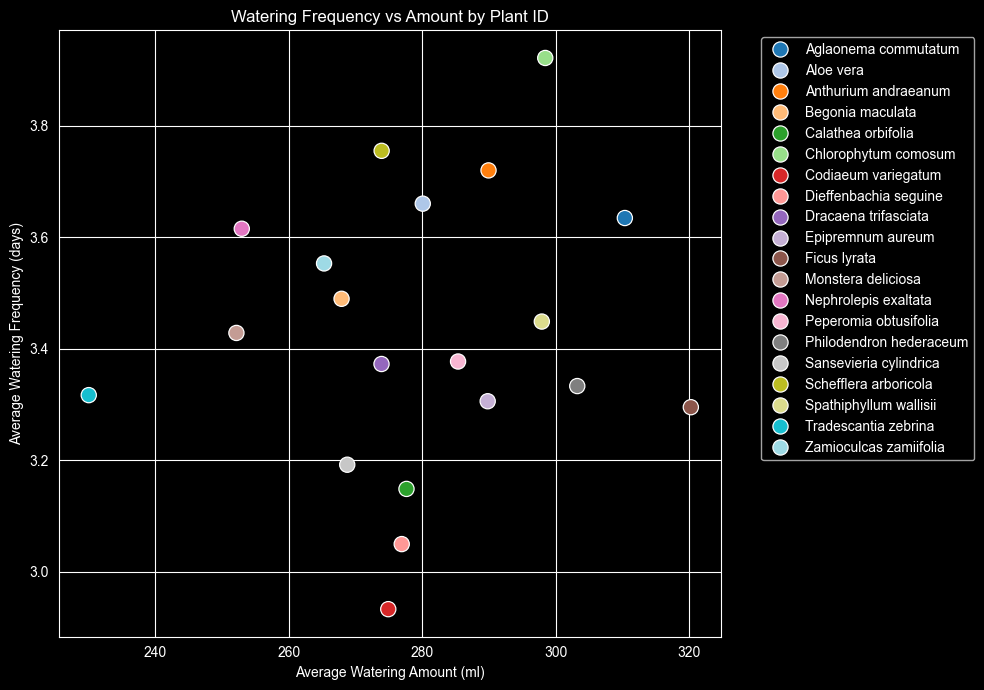

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=plant_water_summary["Watering_Amount_ml"],
    y=plant_water_summary["Watering_Frequency_days"],
    hue=plant_water_summary["Plant_ID"],
    palette="tab20",
    s=120,
    legend="full"
)

plt.title("Watering Frequency vs Amount by Plant ID")
plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



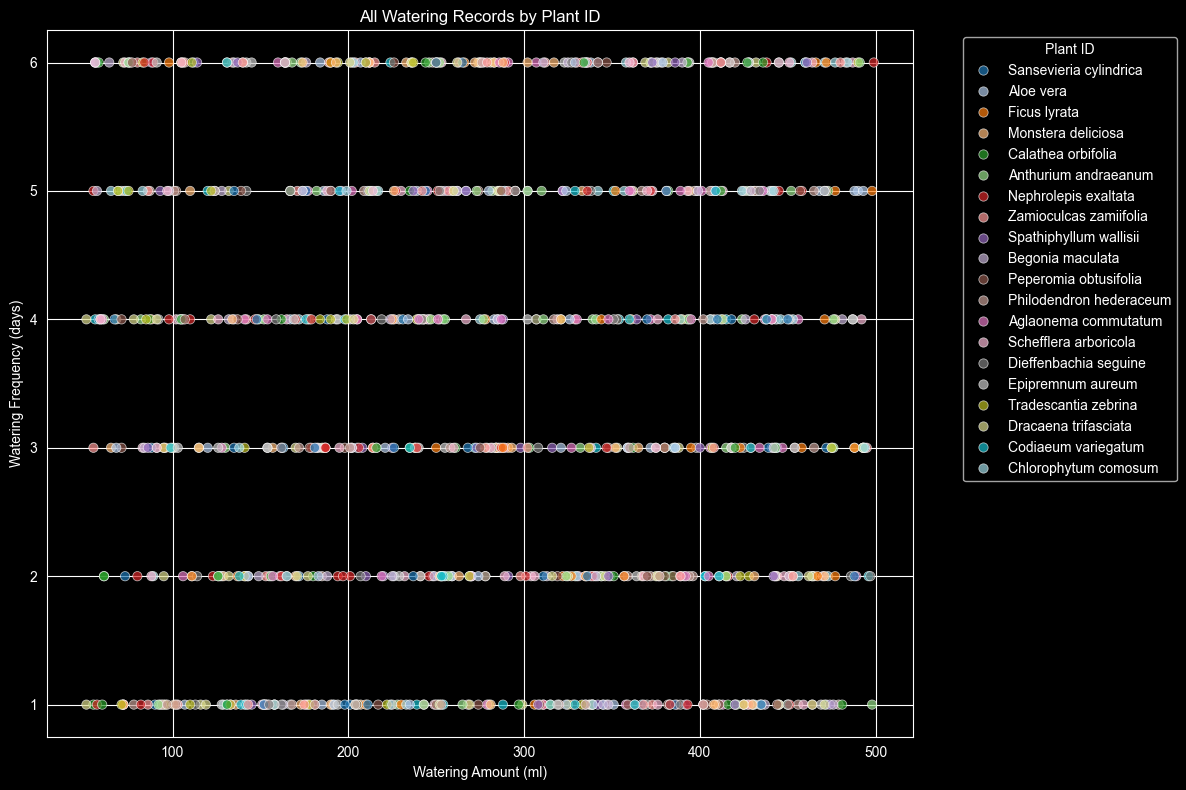

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_clean,
    x="Watering_Amount_ml",
    y="Watering_Frequency_days",
    hue="Plant_ID",
    palette="tab20",
    alpha=0.7,
    s=45
)

plt.title("All Watering Records by Plant ID")
plt.xlabel("Watering Amount (ml)")
plt.ylabel("Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Plant ID")
plt.tight_layout()
plt.show()

In [52]:
from sklearn.cluster import KMeans
import pandas as pd

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_water_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print()

k = 3
0     5
1    10
2     5
Name: count, dtype: int64

k = 4
0    4
1    6
2    5
3    5
Name: count, dtype: int64

k = 5
0    5
1    5
2    5
3    1
4    4
Name: count, dtype: int64

k = 6
0    4
1    5
2    1
3    5
4    1
5    4
Name: count, dtype: int64



k = 4 looks the most balanced so we can go with that on for now

In [53]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()

cluster_features = ["Watering_Amount_ml", "Watering_Frequency_days"]

scaler = StandardScaler()
plant_water_scaled = scaler.fit_transform(plant_water_summary[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_water_summary["Water_Group"] = kmeans.fit_predict(plant_water_scaled)

print(plant_water_summary)

                   Plant_ID  Watering_Amount_ml  Watering_Frequency_days  \
0      Aglaonema commutatum          310.326923                 3.634615   
1                 Aloe vera          280.075472                 3.660377   
2      Anthurium andraeanum          289.920000                 3.720000   
3          Begonia maculata          267.918367                 3.489796   
4        Calathea orbifolia          277.638298                 3.148936   
5      Chlorophytum comosum          298.411765                 3.921569   
6       Codiaeum variegatum          274.911111                 2.933333   
7     Dieffenbachia seguine          276.925000                 3.050000   
8      Dracaena trifasciata          273.898305                 3.372881   
9         Epipremnum aureum          289.795918                 3.306122   
10             Ficus lyrata          320.204545                 3.295455   
11       Monstera deliciosa          252.178571                 3.428571   
12     Nephr

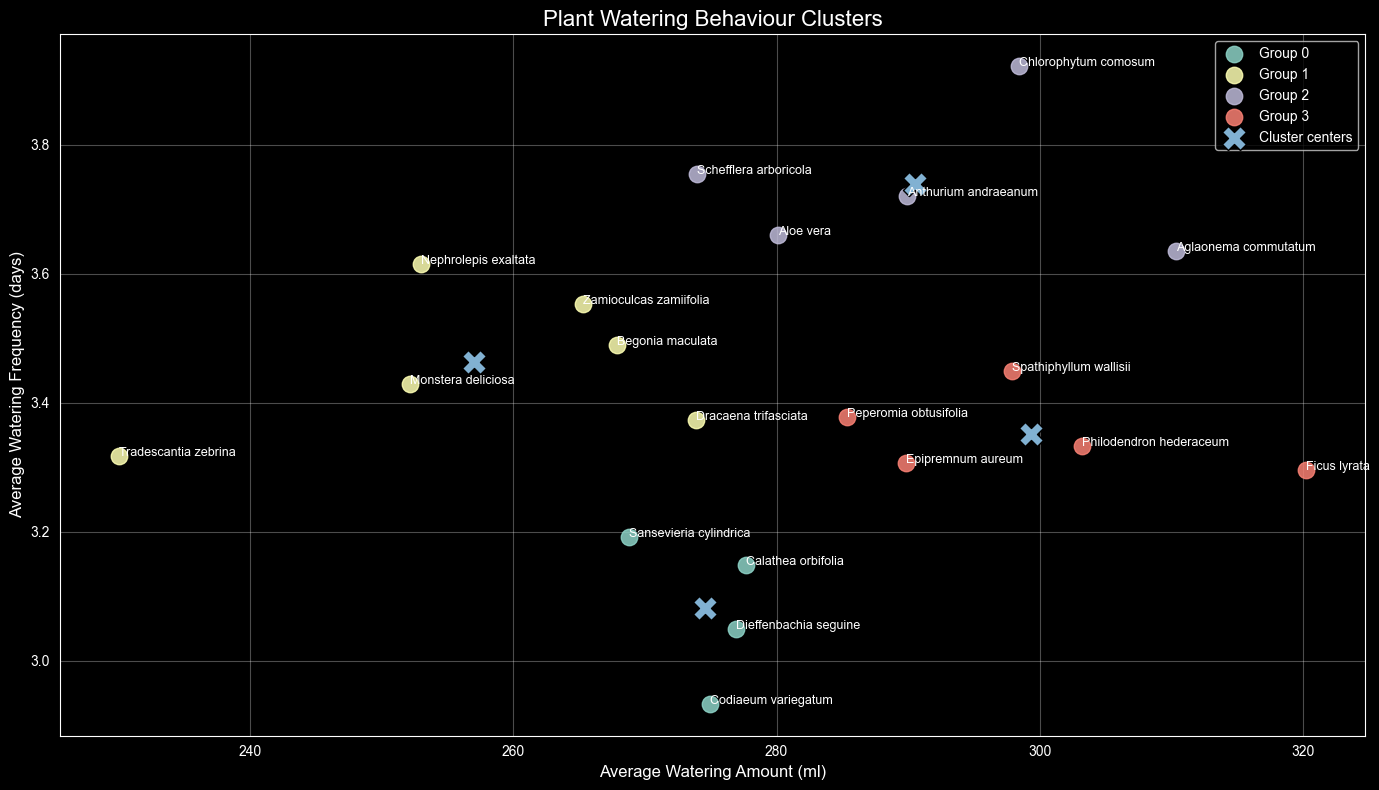

In [55]:
import matplotlib.pyplot as plt

plant_water_summary["Short_Name"] = plant_water_summary["Plant_ID"].apply(
    lambda name: " ".join(name.split()[:2])
)

plt.figure(figsize=(14, 8))
texts = []

for group in sorted(plant_water_summary["Water_Group"].unique()):
    group_data = plant_water_summary[plant_water_summary["Water_Group"] == group]

    plt.scatter(
        group_data["Watering_Amount_ml"],
        group_data["Watering_Frequency_days"],
        label=f"Group {group}",
        s=140,
        alpha=0.85
    )

    for _, row in group_data.iterrows():
        texts.append(
            plt.text(
                row["Watering_Amount_ml"],
                row["Watering_Frequency_days"],
                row["Short_Name"],
                fontsize=9
            )
        )

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    label="Cluster centers",
    edgecolors="black"
)



plt.xlabel("Average Watering Amount (ml)", fontsize=12)
plt.ylabel("Average Watering Frequency (days)", fontsize=12)
plt.title("Plant Watering Behaviour Clusters", fontsize=16)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

this clustering looks pretty good we have now 4 categories with diferent watering behaviour. so from 20 diferent plants we have 4 categories

so lets add it to the dataset

In [56]:
water_group_mapping = plant_water_summary[["Plant_ID", "Water_Group"]]

df_clean = df_clean.merge(
    water_group_mapping,
    on="Plant_ID",
    how="left"
)

print(df_clean[["Plant_ID", "Water_Group"]].head(20))
print(df_clean["Water_Group"].value_counts().sort_index())

                   Plant_ID  Water_Group
0    Sansevieria cylindrica            0
1                 Aloe vera            2
2              Ficus lyrata            3
3        Monstera deliciosa            1
4              Ficus lyrata            3
5              Ficus lyrata            3
6        Calathea orbifolia            0
7      Anthurium andraeanum            2
8              Ficus lyrata            3
9      Anthurium andraeanum            2
10     Nephrolepis exaltata            1
11   Zamioculcas zamiifolia            1
12       Monstera deliciosa            1
13   Spathiphyllum wallisii            3
14   Zamioculcas zamiifolia            1
15         Begonia maculata            1
16    Peperomia obtusifolia            3
17       Monstera deliciosa            1
18  Philodendron hederaceum            3
19     Aglaonema commutatum            2
Water_Group
0    184
1    304
2    255
3    249
Name: count, dtype: int64


looks that its quite okay distribution

In [57]:
print("Missing Water_Group:", df_clean["Water_Group"].isnull().sum())

Missing Water_Group: 0


no failed mapping... perfect

In [58]:
df_model = df_clean.drop(columns=["Plant_ID"])
df_model

,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty,Water_Group
0,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0,0
1,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0,2
2,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0,3
3,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0,1
4,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0,0
988,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1,2
989,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0,1
990,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0,3


In [59]:
print(df_model.info())
print(df_model.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Height_cm                992 non-null    float64
 1   Leaf_Count               992 non-null    int64  
 2   New_Growth_Count         992 non-null    int64  
 3   Watering_Amount_ml       992 non-null    int64  
 4   Watering_Frequency_days  992 non-null    int64  
 5   Room_Temperature_C       992 non-null    float64
 6   Humidity_%               992 non-null    float64
 7   Soil_Moisture_%          992 non-null    float64
 8   Health_Score             992 non-null    int64  
 9   Light                    992 non-null    int64  
 10  Soil_Chalky              992 non-null    int64  
 11  Soil_Clay                992 non-null    int64  
 12  Soil_Loamy               992 non-null    int64  
 13  Soil_Peaty               992 non-null    int64  
 14  Soil_Sandy               992 non-null

In [60]:
print(df_model.describe())

        Height_cm  Leaf_Count  New_Growth_Count  Watering_Amount_ml  \
count  992.000000  992.000000        992.000000          992.000000   
mean    25.947429   27.042339          4.516129          279.678427   
std     10.186447   12.767194          2.848290          124.702829   
min      0.480000    5.000000          0.000000           51.000000   
25%     19.197500   16.000000          2.000000          175.750000   
50%     26.070000   26.000000          5.000000          279.000000   
75%     32.690000   38.000000          7.000000          389.000000   
max     57.600000   49.000000          9.000000          499.000000   

       Watering_Frequency_days  Room_Temperature_C  Humidity_%  \
count               992.000000          992.000000  992.000000   
mean                  3.436492           23.950907   54.716734   
std                   1.751459            3.168924   14.422219   
min                   1.000000           14.300000   30.000000   
25%                   2.000000

In [61]:
print(df_model["Water_Group"].value_counts().sort_index())
print(df_model["Water_Group"].unique())

Water_Group
0    184
1    304
2    255
3    249
Name: count, dtype: int64
[0 2 3 1]


In [62]:
correlations = df_model.corr(numeric_only=True)["Watering_Amount_ml"].sort_values(ascending=False)
print(correlations)

Watering_Amount_ml         1.000000
Water_Group                0.101554
Height_cm                  0.059931
Soil_Moisture_%            0.032227
Soil_Loamy                 0.029085
Soil_Clay                  0.017002
Soil_Sandy                 0.016022
Light                      0.007971
New_Growth_Count           0.002425
Room_Temperature_C        -0.003986
Watering_Frequency_days   -0.009844
Soil_Chalky               -0.010233
Humidity_%                -0.010803
Leaf_Count                -0.014540
Health_Score              -0.023471
Soil_Peaty                -0.025278
Soil_Silty                -0.026449
Name: Watering_Amount_ml, dtype: float64


In [63]:
print("Duplicate rows:", df_model.duplicated().sum())

Duplicate rows: 0


In [64]:
# df_clean[Plant_ID] one hot encoding
df_clean.drop

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty,Water_Group
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0,0
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0,2
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0,3
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0,1
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0,0
988,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1,2
989,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0,1
990,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0,3


trying some other clustering and stuff

In [65]:
df_clean = df_clean.drop(columns=["Water_Group"])

plant_profile = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean",
    "Soil_Moisture_%": "mean",
    "Light": "mean",
    "Room_Temperature_C": "mean",
    "Humidity_%": "mean",
    "Health_Score": "mean"
}).reset_index()

Then scale and reduce dimensions with PCA:

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

scaler = StandardScaler()
plant_profile_scaled = scaler.fit_transform(plant_profile[profile_features])

pca = PCA(n_components=2)
plant_profile_pca = pca.fit_transform(plant_profile_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

Explained variance: [0.27817754 0.21850319]
Total explained: 0.4966807353631653


Then cluster

In [69]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_profile_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(plant_profile_scaled, labels))

    print("k =", k)
    print("Cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(plant_profile_scaled, labels))
    print()

k = 2
Cluster sizes:
0    12
1     8
Name: count, dtype: int64
Silhouette: 0.1470512609261275

k = 3
Cluster sizes:
0     8
1    10
2     2
Name: count, dtype: int64
Silhouette: 0.13617862897521335

k = 4
Cluster sizes:
0    3
1    7
2    7
3    3
Name: count, dtype: int64
Silhouette: 0.15826871692589328

k = 5
Cluster sizes:
0    5
1    3
2    5
3    3
4    4
Name: count, dtype: int64
Silhouette: 0.11424548838575763

k = 6
Cluster sizes:
0    4
1    3
2    8
3    1
4    2
5    2
Name: count, dtype: int64
Silhouette: 0.12337030133149936

k = 7
Cluster sizes:
0    1
1    7
2    1
3    2
4    6
5    1
6    2
Name: count, dtype: int64
Silhouette: 0.10474278122125753

k = 8
Cluster sizes:
0    1
1    5
2    4
3    5
4    2
5    1
6    1
7    1
Name: count, dtype: int64
Silhouette: 0.1035711506079362



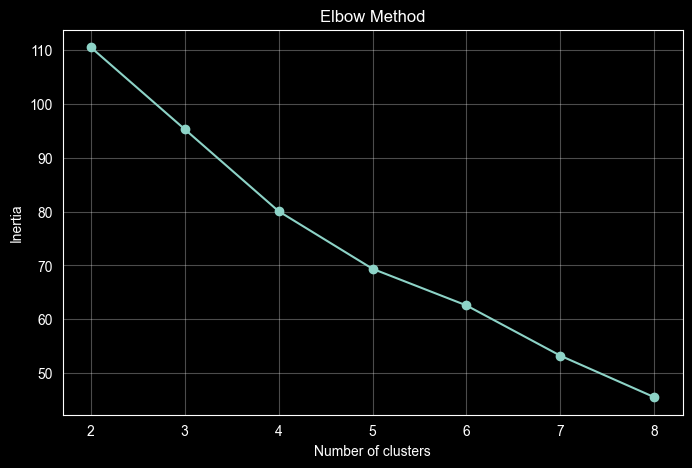

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True, alpha=0.3)
plt.show()

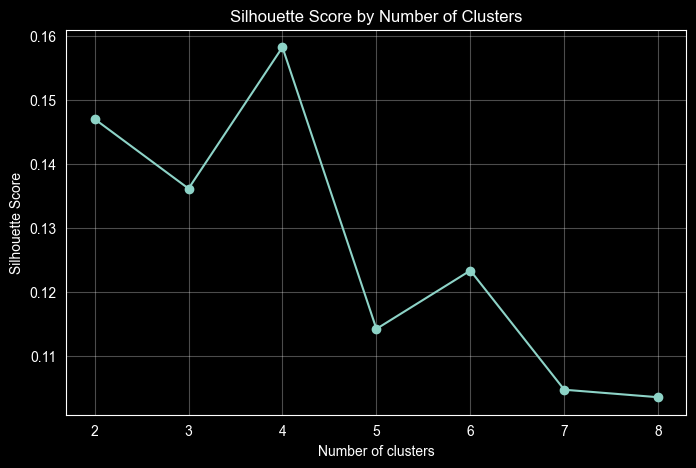

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.grid(True, alpha=0.3)
plt.show()

We tested several cluster counts using elbow and silhouette analysis. k=4 gave the best silhouette score while keeping cluster sizes reasonably balanced, so we used 4 watering profile groups for the prototype.

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

scaler = StandardScaler()
plant_profile_scaled = scaler.fit_transform(plant_profile[profile_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_profile["Water_Group"] = kmeans.fit_predict(plant_profile_scaled)

print("Cluster sizes:")
print(plant_profile["Water_Group"].value_counts().sort_index())

print("Silhouette:")
print(silhouette_score(plant_profile_scaled, plant_profile["Water_Group"]))

pca = PCA(n_components=2)
plant_profile_pca = pca.fit_transform(plant_profile_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())

plant_profile["PC1"] = plant_profile_pca[:, 0]
plant_profile["PC2"] = plant_profile_pca[:, 1]

Cluster sizes:
Water_Group
0    3
1    7
2    7
3    3
Name: count, dtype: int64
Silhouette:
0.15826871692589328
Explained variance: [0.27817754 0.21850319]
Total explained: 0.4966807353631653


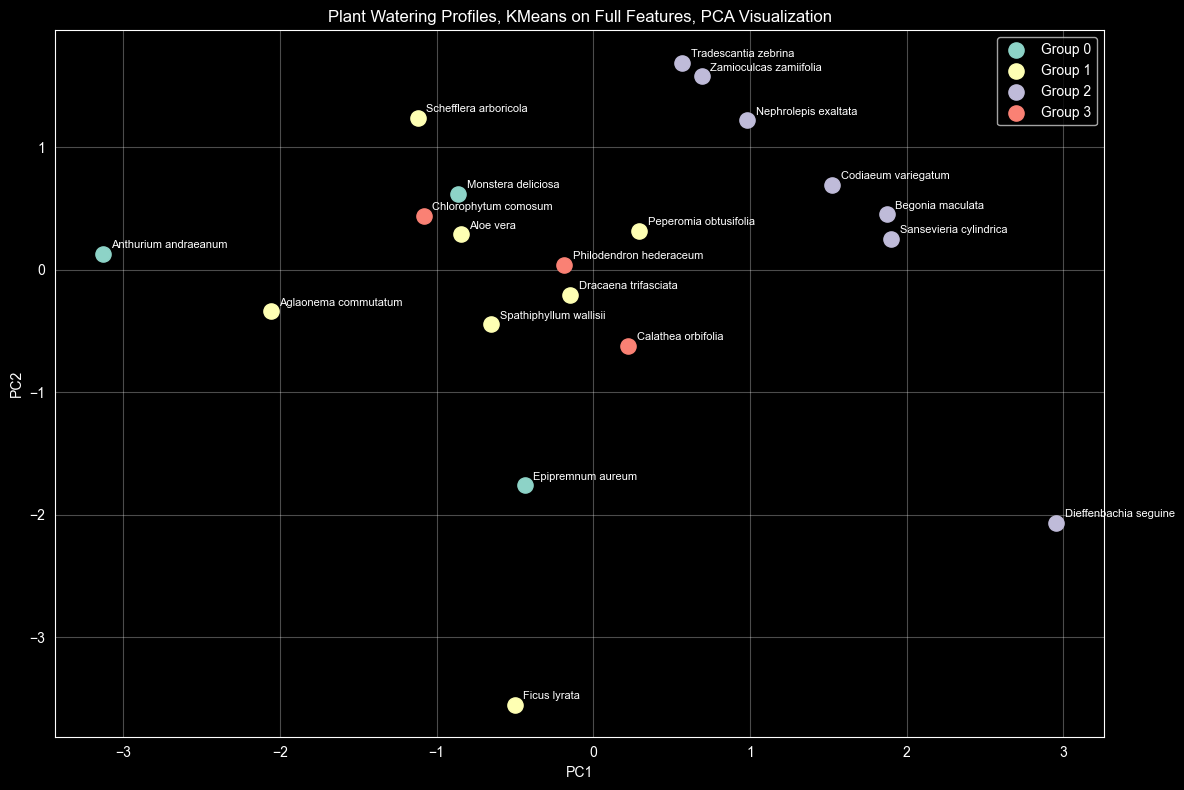

In [73]:
plt.figure(figsize=(12, 8))

for group in sorted(plant_profile["Water_Group"].unique()):
    group_data = plant_profile[plant_profile["Water_Group"] == group]

    plt.scatter(
        group_data["PC1"],
        group_data["PC2"],
        label=f"Group {group}",
        s=120
    )

    for _, row in group_data.iterrows():
        plt.annotate(
            row["Plant_ID"],
            (row["PC1"], row["PC2"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Plant Watering Profiles, KMeans on Full Features, PCA Visualization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

KMeans on 7-dimensional scaled features
→ then projected down to 2D with PCA for visualization

The clusters exist, but they are only weakly separated
bc silhouette score was only: 0.158

In [76]:
plant_profile.groupby("Water_Group")[[
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]].mean()

,Watering_Amount_ml,Watering_Frequency_days,Soil_Moisture_%,Light,Room_Temperature_C,Humidity_%,Health_Score
Water_Group,,,,,,,
0,277.298163,3.484898,33.273041,437.749422,23.875422,53.703939,2.787585
1,291.668580,3.506396,33.171800,547.232089,23.656312,54.403679,3.053524
2,262.410789,3.307298,35.468893,528.560544,24.228399,56.030629,3.191153
3,293.084589,3.467946,38.058188,511.044230,24.071926,53.711749,2.884779


okay this looks like shit
lets start again


In [77]:
profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

print(plant_profile[profile_features].skew().sort_values(ascending=False))

Soil_Moisture_%            0.519574
Humidity_%                 0.442187
Watering_Frequency_days   -0.020165
Watering_Amount_ml        -0.245385
Health_Score              -0.546421
Light                     -0.662784
Room_Temperature_C        -1.317619
dtype: float64


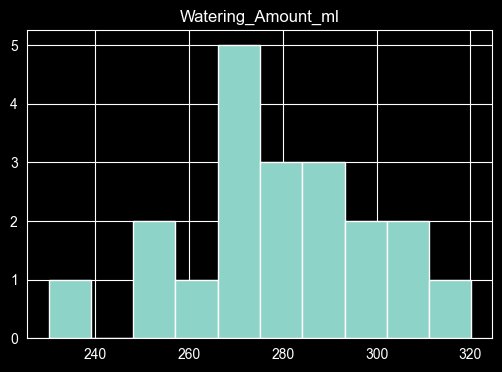

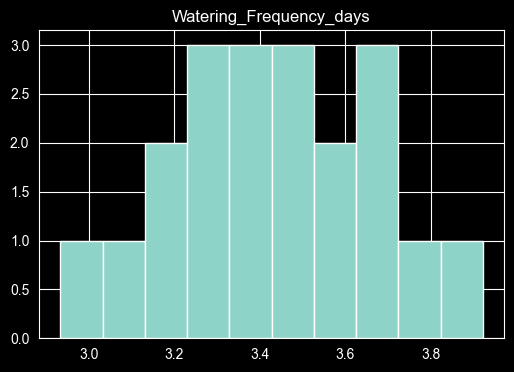

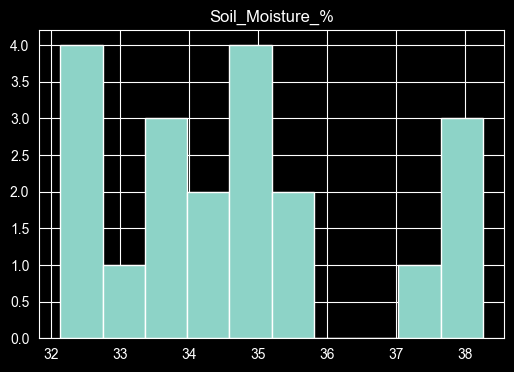

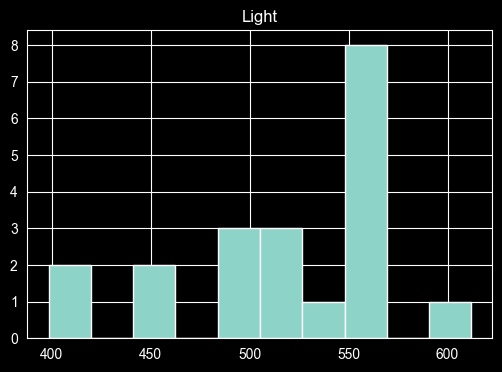

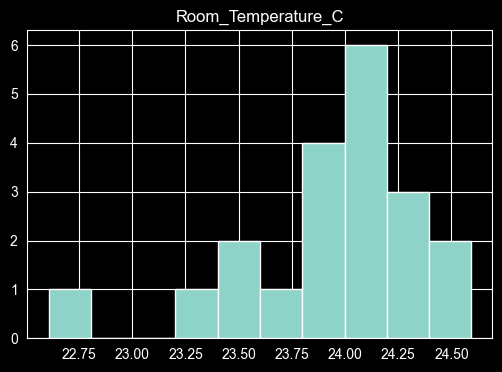

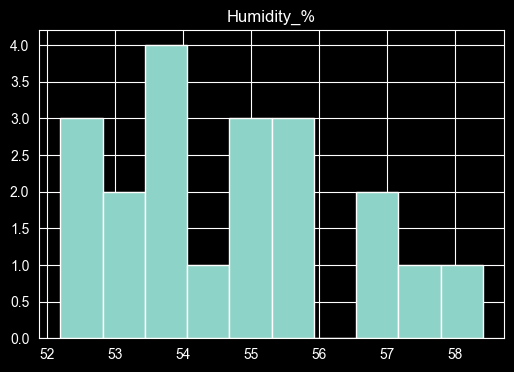

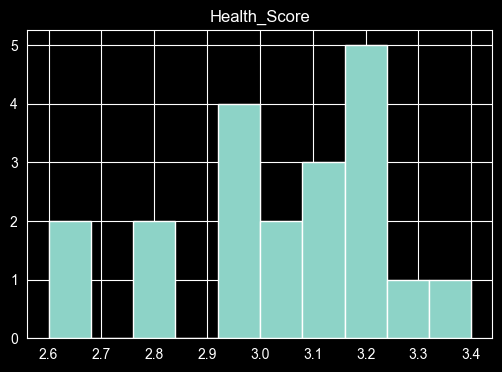

In [78]:
import matplotlib.pyplot as plt

for col in profile_features:
    plt.figure(figsize=(6, 4))
    plant_profile[col].hist(bins=10)
    plt.title(col)
    plt.show()

In [79]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

profile_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

transform_pipeline = Pipeline([
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

plant_profile_transformed = transform_pipeline.fit_transform(
    plant_profile[profile_features]
)

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_profile_transformed)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(plant_profile_transformed, labels))
    print()

k = 2
0    12
1     8
Name: count, dtype: int64
Silhouette: 0.1591249268007363

k = 3
0    8
1    5
2    7
Name: count, dtype: int64
Silhouette: 0.14456380249946393

k = 4
0    6
1    7
2    2
3    5
Name: count, dtype: int64
Silhouette: 0.13741489235309196

k = 5
0    4
1    7
2    2
3    4
4    3
Name: count, dtype: int64
Silhouette: 0.11661955075366341

k = 6
0    2
1    2
2    3
3    6
4    6
5    1
Name: count, dtype: int64
Silhouette: 0.11038788573048264

k = 7
0    2
1    6
2    2
3    3
4    4
5    1
6    2
Name: count, dtype: int64
Silhouette: 0.1075591710515759

k = 8
0    5
1    5
2    2
3    1
4    1
5    2
6    1
7    3
Name: count, dtype: int64
Silhouette: 0.1153311135174411



yup clustering is weak. not even transformation helped

Before transformation:
best was k=4, silhouette ≈ 0.158

After transformation:
best is k=2, silhouette ≈ 0.159

We tested KMeans clustering on plant-level watering profiles. Features were scaled, and skewness was checked. A Yeo-Johnson power transformation was also tested to reduce skewness before clustering. However, silhouette scores remained low, around 0.16, meaning the clusters were weakly separated. Therefore, the dataset does not provide strong evidence for natural watering profile groups.

okay lets try other stuff
worth trying and probably not worth it.

### Cluster only on the real watering behaviour

In [80]:
features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

X = plant_profile[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

k = 2
0    10
1    10
Name: count, dtype: int64
Silhouette: 0.30505294182067166

k = 3
0     5
1    10
2     5
Name: count, dtype: int64
Silhouette: 0.3544160224258025

k = 4
0    4
1    6
2    5
3    5
Name: count, dtype: int64
Silhouette: 0.4064425248057857

k = 5
0    5
1    5
2    5
3    1
4    4
Name: count, dtype: int64
Silhouette: 0.3886405243301521

k = 6
0    4
1    5
2    1
3    5
4    1
5    4
Name: count, dtype: int64
Silhouette: 0.33108285416652306



### hierarchical clustering

In [85]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(plant_profile[features])

for k in range(2, 7):
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

k = 2
0    18
1     2
Name: count, dtype: int64
Silhouette: 0.23687032404837494

k = 3
0    9
1    2
2    9
Name: count, dtype: int64
Silhouette: 0.10271768939394685

k = 4
0    9
1    2
2    5
3    4
Name: count, dtype: int64
Silhouette: 0.0996474872742068

k = 5
0    4
1    2
2    5
3    4
4    5
Name: count, dtype: int64
Silhouette: 0.11140180916572928

k = 6
0    2
1    2
2    5
3    4
4    5
5    2
Name: count, dtype: int64
Silhouette: 0.1343932386567597



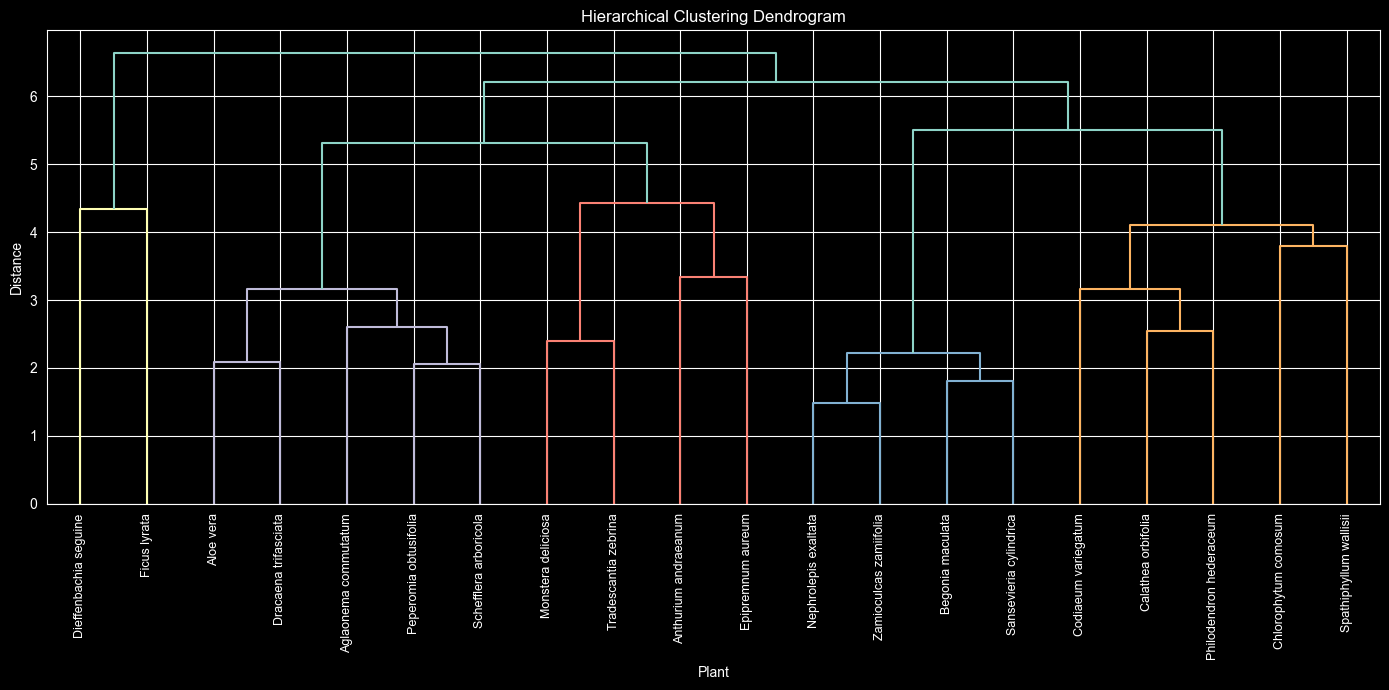

In [98]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(plant_profile[features])

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    labels=plant_profile["Plant_ID"].values,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

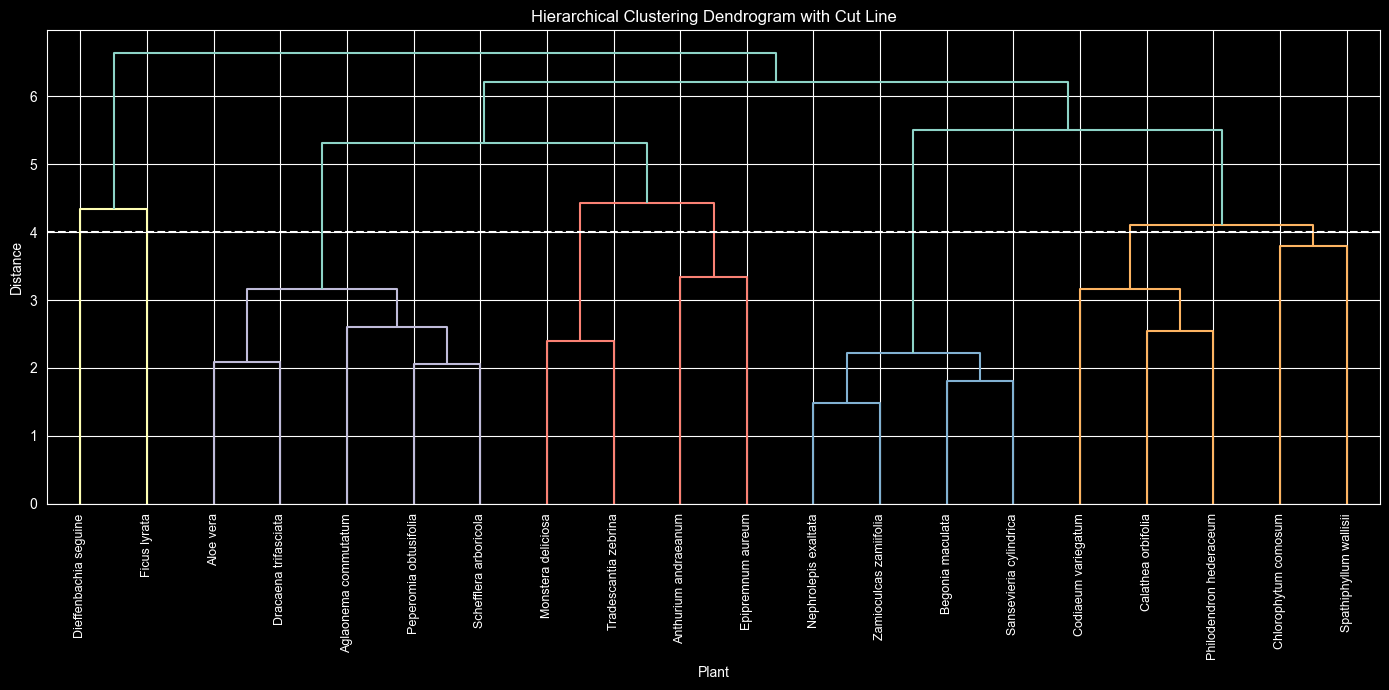

In [99]:
plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    labels=plant_profile["Plant_ID"].values,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.axhline(y=4, linestyle="--")

plt.title("Hierarchical Clustering Dendrogram with Cut Line")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### DBSCAN

In [89]:
from sklearn.cluster import DBSCAN

for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    model = DBSCAN(eps=eps, min_samples=2)
    labels = model.fit_predict(X_scaled)

    print("eps =", eps)
    print(pd.Series(labels).value_counts().sort_index())
    print()

eps = 0.8
-1     885
 0       2
 1       2
 2       2
 3       2
 4       2
 5       2
 6       3
 7       2
 8       3
 9       3
 10      3
 11      2
 12      2
 13      2
 14      2
 15      2
 16      2
 17      2
 18      2
 19      2
 20      2
 21      3
 22      2
 23      2
 24      2
 25      2
 26      2
 27      3
 28      2
 29      2
 30      3
 31      2
 32      2
 33      2
 34      2
 35      2
 36      2
 37      2
 38      2
 39      2
 40      2
 41      2
 42      2
 43      2
 44      2
 45      2
 46      2
 47      2
 48      2
 49      2
Name: count, dtype: int64

eps = 1.0
-1      646
 0        2
 1        8
 2        2
 3        2
       ... 
 122      2
 123      2
 124      2
 125      2
 126      2
Name: count, Length: 128, dtype: int64

eps = 1.2
-1     309
 0     283
 1       2
 2      57
 3      11
      ... 
 84      2
 85      2
 86      2
 87      2
 88      2
Name: count, Length: 90, dtype: int64

eps = 1.5
-1     49
 0    929
 1      2
 2      2


### clustering full rows instead of plant averages

In [90]:
features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Soil_Moisture_%",
    "Light",
    "Room_Temperature_C",
    "Humidity_%",
    "Health_Score"
]

X_scaled = StandardScaler().fit_transform(df_model[features])

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print("Silhouette:", silhouette_score(X_scaled, labels))
    print()

k = 2
0    480
1    512
Name: count, dtype: int64
Silhouette: 0.11224326607397059

k = 3
0    310
1    350
2    332
Name: count, dtype: int64
Silhouette: 0.10484623811797832

k = 4
0    259
1    233
2    269
3    231
Name: count, dtype: int64
Silhouette: 0.10527864058603008

k = 5
0    208
1    210
2    197
3    192
4    185
Name: count, dtype: int64
Silhouette: 0.10898036386767457

k = 6
0    162
1    168
2    156
3    161
4    157
5    188
Name: count, dtype: int64
Silhouette: 0.11464221719225477

k = 7
0    152
1    158
2    145
3    138
4    131
5    125
6    143
Name: count, dtype: int64
Silhouette: 0.11549109822532129

k = 8
0    120
1    106
2    128
3    128
4    124
5    127
6    145
7    114
Name: count, dtype: int64
Silhouette: 0.12045477451201961



binning watering amount instead of clustering

In [91]:
df_model["Watering_Category"] = pd.cut(
    df_model["Watering_Amount_ml"],
    bins=[0, 180, 350, 500],
    labels=["low", "medium", "high"]
)

print(df_model["Watering_Category"].value_counts())

Watering_Category
medium    392
high      338
low       262
Name: count, dtype: int64


Several clustering approaches were tested. Clustering on the full environmental feature set produced weak separation, with silhouette scores around 0.15. After narrowing the clustering features to the two variables that directly describe watering behaviour, average watering amount and watering frequency, the clusters became more meaningful. KMeans with k=4 achieved the best silhouette score of 0.406 while keeping balanced cluster sizes. Therefore, four plant watering profile groups were selected for the prototype.

In [92]:
water_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

plant_water_summary = df_clean.groupby("Plant_ID")[water_features].mean().reset_index()

scaler = StandardScaler()
plant_water_scaled = scaler.fit_transform(plant_water_summary[water_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_water_summary["Water_Group"] = kmeans.fit_predict(plant_water_scaled)

print(
    plant_water_summary
    .sort_values(["Water_Group", "Watering_Amount_ml", "Watering_Frequency_days"])
)

                   Plant_ID  Watering_Amount_ml  Watering_Frequency_days  \
15   Sansevieria cylindrica          268.769231                 3.192308   
6       Codiaeum variegatum          274.911111                 2.933333   
7     Dieffenbachia seguine          276.925000                 3.050000   
4        Calathea orbifolia          277.638298                 3.148936   
18     Tradescantia zebrina          230.073171                 3.317073   
11       Monstera deliciosa          252.178571                 3.428571   
12     Nephrolepis exaltata          252.980769                 3.615385   
19   Zamioculcas zamiifolia          265.297872                 3.553191   
3          Begonia maculata          267.918367                 3.489796   
8      Dracaena trifasciata          273.898305                 3.372881   
16    Schefflera arboricola          273.918367                 3.755102   
1                 Aloe vera          280.075472                 3.660377   
2      Anthu

In [94]:
print(
    plant_water_summary.groupby("Water_Group")[[
        "Watering_Amount_ml",
        "Watering_Frequency_days"
    ]].mean()
)

             Watering_Amount_ml  Watering_Frequency_days
Water_Group                                             
0                    274.560910                 3.081144
1                    257.057843                 3.462816
2                    290.530505                 3.738333
3                    299.292123                 3.352250


In [95]:
print(
    plant_water_summary.groupby("Water_Group")[[
        "Watering_Amount_ml",
        "Watering_Frequency_days"
    ]].agg(["mean", "min", "max", "count"])
)

            Watering_Amount_ml                                \
                          mean         min         max count   
Water_Group                                                    
0                   274.560910  268.769231  277.638298     4   
1                   257.057843  230.073171  273.898305     6   
2                   290.530505  273.918367  310.326923     5   
3                   299.292123  285.358491  320.204545     5   

            Watering_Frequency_days                            
                               mean       min       max count  
Water_Group                                                    
0                          3.081144  2.933333  3.192308     4  
1                          3.462816  3.317073  3.615385     6  
2                          3.738333  3.634615  3.921569     5  
3                          3.352250  3.295455  3.448980     5  


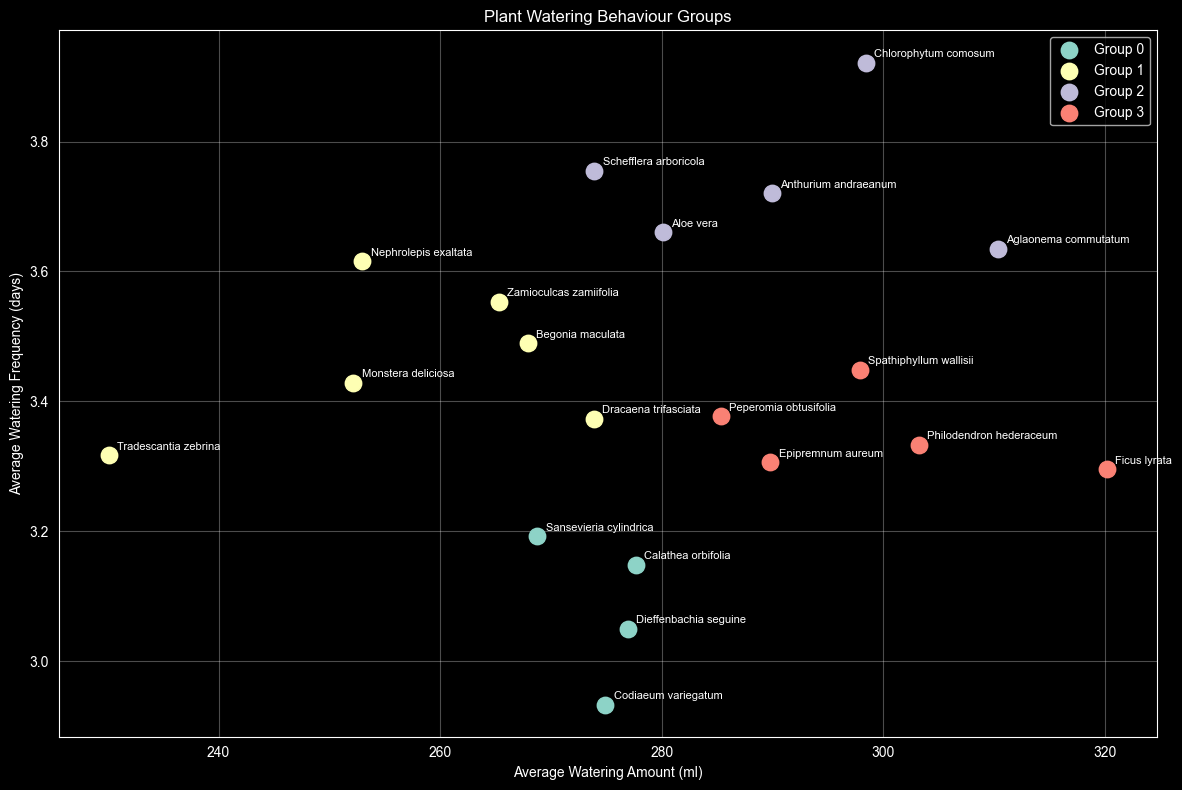

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for group in sorted(plant_water_summary["Water_Group"].unique()):
    group_data = plant_water_summary[plant_water_summary["Water_Group"] == group]

    plt.scatter(
        group_data["Watering_Amount_ml"],
        group_data["Watering_Frequency_days"],
        label=f"Group {group}",
        s=140
    )

    for _, row in group_data.iterrows():
        plt.annotate(
            row["Plant_ID"],
            (row["Watering_Amount_ml"], row["Watering_Frequency_days"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.title("Plant Watering Behaviour Groups")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()